In [5]:
import pandas as pd
df= pd.read_csv("Datasets/Accidentes_Viales_20260216.csv")
df.head()

,Fecha_Ocurrencia;Codigo_Accidente;Direccion;Barrio;Vehiculos Involucrados;Heridos;Accidente con;Muertes;Clase de Accidente
0,2024 Jan 03 12:00:00 AM;A001602262;CALLE 14A C...
1,2024 Jan 06 12:00:00 AM;A001602263;CALLE 14 CA...
2,2024 Jan 09 12:00:00 AM;A001602264;KILOMETRO 7...
3,2024 Jan 12 12:00:00 AM;A001602265;AVENIDA 23 ...
4,2024 Jan 12 12:00:00 AM;A001602266;KILOMETRO 3...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   Fecha_Ocurrencia;Codigo_Accidente;Direccion;Barrio;Vehiculos Involucrados;Heridos;Accidente con;Muertes;Clase de Accidente  512 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [7]:
df= pd.read_csv("Datasets/Accidentes_Viales_20260216.csv", sep=';')
df.columns

Index(['Fecha_Ocurrencia', 'Codigo_Accidente', 'Direccion', 'Barrio',
       'Vehiculos Involucrados', 'Heridos', 'Accidente con', 'Muertes',
       'Clase de Accidente'],
      dtype='object')

In [8]:
df.info

<bound method DataFrame.info of             Fecha_Ocurrencia Codigo_Accidente  \
0    2024 Jan 03 12:00:00 AM       A001602262   
1    2024 Jan 06 12:00:00 AM       A001602263   
2    2024 Jan 09 12:00:00 AM       A001602264   
3    2024 Jan 12 12:00:00 AM       A001602265   
4    2024 Jan 12 12:00:00 AM       A001602266   
..                       ...              ...   
507  2022 Dec 18 12:00:00 AM       A001456881   
508  2022 Dec 17 12:00:00 AM       A001456880   
509  2022 Dec 29 12:00:00 AM       A001456883   
510  2022 Dec 28 12:00:00 AM       A001456882   
511  2022 Dec 27 12:00:00 AM      C-001482414   

                                             Direccion  \
0                        CALLE 14A CARRERA 34   BACHUE   
1                     CALLE 14 CARRERA  28   SAN JOSÃ‰   
2                                  KILOMETRO 7+800 MTS   
3                      AVENIDA 23 N. 24 - 07   LA TIZA   
4    KILOMETRO 3+500 MTS VIA CHICHIMENE ESTACION AC...   
..                             

In [9]:
df['Fecha_Ocurrencia']= pd.to_datetime(df['Fecha_Ocurrencia'],errors='coerce')
df['Año']=df['Fecha_Ocurrencia'].dt.year
df['Mes']=df['Fecha_Ocurrencia'].dt.month
df['Dia']=df['Fecha_Ocurrencia'].dt.day
df['Dia_semana']=df['Fecha_Ocurrencia'].dt.day_name()
df.head()

C:\Users\caror\AppData\Local\Temp\ipykernel_15008\639571227.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha_Ocurrencia']= pd.to_datetime(df['Fecha_Ocurrencia'],errors='coerce')


,Fecha_Ocurrencia,Codigo_Accidente,Direccion,Barrio,Vehiculos Involucrados,Heridos,Accidente con,Muertes,Clase de Accidente,Año,Mes,Dia,Dia_semana
0,2024-01-03,A001602262,CALLE 14A CARRERA 34 BACHUE,BACHUE,2,2,HERIDOS,0,CHOQUE,2024,1,3,Wednesday
1,2024-01-06,A001602263,CALLE 14 CARRERA 28 SAN JOSÃ‰,SAN JOSÃ‰,2,3,HERIDOS,0,CHOQUE,2024,1,6,Saturday
2,2024-01-09,A001602264,KILOMETRO 7+800 MTS,No registra,1,1,HERIDOS,0,CHOQUE,2024,1,9,Tuesday
3,2024-01-12,A001602265,AVENIDA 23 N. 24 - 07 LA TIZA,LA TIZA,2,2,HERIDOS,0,CHOQUE,2024,1,12,Friday
4,2024-01-12,A001602266,KILOMETRO 3+500 MTS VIA CHICHIMENE ESTACION AC...,No registra,2,1,HERIDOS,0,CHOQUE,2024,1,12,Friday


In [10]:
df['Heridos']= pd.to_numeric(df['Heridos'], errors='coerce')
df['Muertes']= pd.to_numeric(df['Muertes'], errors='coerce')

In [11]:
df.isnull().sum()

Fecha_Ocurrencia            0
Codigo_Accidente            0
Direccion                   0
Barrio                      0
Vehiculos Involucrados      0
Heridos                     0
Accidente con               0
Muertes                   453
Clase de Accidente          0
Año                         0
Mes                         0
Dia                         0
Dia_semana                  0
dtype: int64

In [12]:
print("Total Accidentes: ", len(df))
print("Total Heridos: ", df['Heridos'].sum())

Total Accidentes:  512
Total Heridos:  665


In [13]:
df['Muertes'].fillna(0)
df['Muertes'].sum()

49.0

In [14]:
df['Muertes'].value_counts()

Muertes
1.0    35
0.0    18
2.0     4
3.0     2
Name: count, dtype: int64

Analisis por Barrio

In [15]:
top_barrios= df['Barrio'].value_counts().head(10)
top_barrios

Barrio
No registra                    115
SIN INFORMACIÃ“N DEL BARRIO     86
VÃA GRANADA-VILLAVICENCIO      50
BACHUE                          27
MANCERA                         24
COOPERATIVO                     22
CENTRO                          21
SAN JOSÃ‰                       15
SAN CRISTOBAL                   13
INDEPENDENCIA                   12
Name: count, dtype: int64

In [16]:
df['Severidad']= df['Muertes'].apply(lambda x :'Fatal' if x > 0 else 'No Fatal')

In [17]:
df['Severidad'].value_counts()

Severidad
No Fatal    471
Fatal        41
Name: count, dtype: int64

In [18]:
df[['Muertes', 'Severidad']].head(50)

,Muertes,Severidad
0,0.0,No Fatal
1,0.0,No Fatal
2,0.0,No Fatal
3,0.0,No Fatal
4,0.0,No Fatal
5,0.0,No Fatal
6,0.0,No Fatal
7,0.0,No Fatal
8,1.0,Fatal
9,0.0,No Fatal


In [19]:
df['Muertes'].isna().sum()

453

In [20]:
df['Muertes']=pd.to_numeric(df['Muertes'],errors='coerce')
df['Muertes']= df['Muertes'].fillna(0)
df['Muertes']=df['Muertes'].astype(int)

In [21]:
df['Muertes'].isna().sum()

0

In [22]:
df['Severidad']= df['Muertes'].apply(lambda x :'Fatal' if x > 0 else 'No Fatal')

In [23]:
df['Severidad'].value_counts()

Severidad
No Fatal    471
Fatal        41
Name: count, dtype: int64

In [24]:
df_fatales= df[df['Severidad']=='Fatal']
df_fatales['Barrio'].value_counts().head(10)

Barrio
No registra                    19
VÃA GRANADA-VILLAVICENCIO      7
SIN INFORMACIÃ“N DEL BARRIO     3
MANCERA                         2
COOPERATIVO                     2
CIMARRON                        1
PABLO EMILIO RIVEROS            1
VÃA ANTIGUA GUAMAL             1
BAQUEROS CLUB-CHICHIMENE        1
DON BOSCO                       1
Name: count, dtype: int64

In [25]:
df['Barrio'].value_counts().head(10)

Barrio
No registra                    115
SIN INFORMACIÃ“N DEL BARRIO     86
VÃA GRANADA-VILLAVICENCIO      50
BACHUE                          27
MANCERA                         24
COOPERATIVO                     22
CENTRO                          21
SAN JOSÃ‰                       15
SAN CRISTOBAL                   13
INDEPENDENCIA                   12
Name: count, dtype: int64

In [26]:
df.groupby('Clase de Accidente')['Muertes'].sum().sort_values(ascending=False)

Clase de Accidente
CHOQUE         44
ATROPELLO       3
OTRO            2
VOLCAMIENTO     0
Name: Muertes, dtype: int32

In [27]:
df['Barrio'].value_counts().head(15)

Barrio
No registra                    115
SIN INFORMACIÃ“N DEL BARRIO     86
VÃA GRANADA-VILLAVICENCIO      50
BACHUE                          27
MANCERA                         24
COOPERATIVO                     22
CENTRO                          21
SAN JOSÃ‰                       15
SAN CRISTOBAL                   13
INDEPENDENCIA                   12
DORADO                          12
PABLO EMILIO RIVEROS            11
POPULAR                          8
VILLA LUCIA                      8
SAMAN                            7
Name: count, dtype: int64

In [28]:
df['Barrio'].unique()

array(['BACHUE', 'SAN JOSÃ‰', 'No registra', 'LA TIZA', 'COOPERATIVO',
       'MANCERA', 'DORADO', 'PABLO EMILIO RIVEROS', 'SAN CRISTOBAL',
       'POPULAR', 'EL BOSQUE', 'COLINAS', 'VILLA LUCIA', 'COMCAJA',
       'VILLA MANUELA', 'SAMAN', 'SIN INFORMACIÃ“N DEL BARRIO',
       'MALECÃ“N TURISTICO', 'CENTRO', 'JUAN MELLAO', 'DORADO BAJO',
       'INDEPENDENCIA', 'ASOCIACIÃ“N DE AMIGOS',
       'VÃ\x8dA GRANADA-VILLAVICENCIO', 'VÃ\x8dA ANTIGUA GUAMAL',
       'CIMARRON', 'BRISAS DE LA COLINA', 'BALCONES DE SAN DIEGO',
       'LA ORQUIDEA REAL', 'VILLA MAGALY', 'VÃ\x8dA PRINCIPAL-AVENIDA 23',
       'VILLA TERESA', 'LAS ACACIAS', 'VILLA DEL LLANO',
       'VÃ\x8dA ACACÃ\x8dAS-VILLAVICENCIO', 'VILLA CASTILLA',
       'VÃ\x8dA ACACÃ\x8dAS-DINAMARCA', 'ATAHUALPA', 'NUTIVARA',
       'BALCONES DE SANTA ISABEL', 'DON BOSCO', 'LA UNION', 'LOS OLIVOS',
       'VÃ\x8dA ACACÃ\x8dAS-GUAMAL', 'GUARATARA II', 'NUEVA JERUSALEN',
       'GUARATARA', 'BAQUEROS CLUB-CHICHIMENE', 'SANTA ISABEL',
       '

In [29]:
df['Barrio']=df['Barrio'].replace(['No registra', 'SIN INFORMACIÃ“N DEL BARRIO'], 'SIN INFORMACION')

In [30]:
df_barrios_validos= df[df['Barrio']!= 'SIN INFORMACION']
df_barrios_validos['Barrio'].value_counts().head(10)

Barrio
VÃA GRANADA-VILLAVICENCIO    50
BACHUE                        27
MANCERA                       24
COOPERATIVO                   22
CENTRO                        21
SAN JOSÃ‰                     15
SAN CRISTOBAL                 13
DORADO                        12
INDEPENDENCIA                 12
PABLO EMILIO RIVEROS          11
Name: count, dtype: int64

In [31]:
df.groupby('Clase de Accidente').agg({
    'Codigo_Accidente': 'count',
    'Muertes' : 'sum',
    'Heridos': 'sum'
}).sort_values(by='Muertes', ascending=False)

,Codigo_Accidente,Muertes,Heridos
Clase de Accidente,,,
CHOQUE,450,44,584
ATROPELLO,54,3,76
OTRO,7,2,5
VOLCAMIENTO,1,0,0


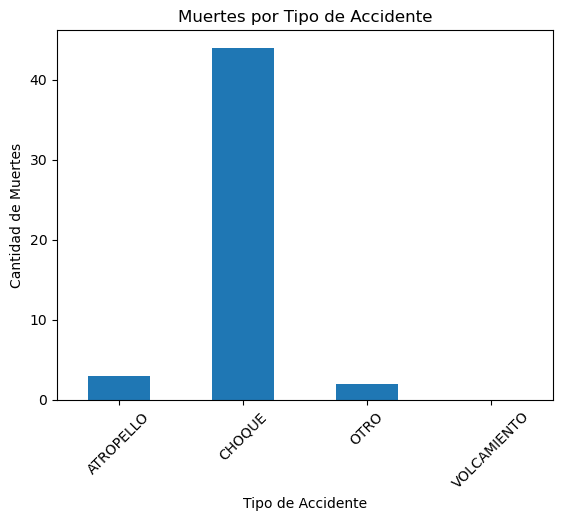

In [34]:
import matplotlib.pyplot as plt

df.groupby('Clase de Accidente')['Muertes'].sum().plot(kind='bar')

plt.title('Muertes por Tipo de Accidente')
plt.ylabel('Cantidad de Muertes')
plt.xlabel('Tipo de Accidente')
plt.xticks(rotation=45)
plt.show()

In [35]:
def clasificar_severidad(row):
    if row['Muertes'] > 0:
        return 'Fatal'
    elif row['Heridos'] > 0:
        return 'Con Heridos'
    else:
        return 'Solo Daños'

df['Severidad'] = df.apply(clasificar_severidad, axis=1)

In [37]:
df['Severidad'].value_counts()

Severidad
Con Heridos    407
Solo Daños      64
Fatal           41
Name: count, dtype: int64

In [36]:
df['Severidad'].value_counts(normalize=True)*100

Severidad
Con Heridos    79.492188
Solo Daños     12.500000
Fatal           8.007812
Name: proportion, dtype: float64

In [38]:
df_modelo= df[['Clase de Accidente', 'Barrio', 'Mes', 'Dia_semana', 'Severidad']]
df_modelo.head()

,Clase de Accidente,Barrio,Mes,Dia_semana,Severidad
0,CHOQUE,BACHUE,1,Wednesday,Con Heridos
1,CHOQUE,SAN JOSÃ‰,1,Saturday,Con Heridos
2,CHOQUE,SIN INFORMACION,1,Tuesday,Con Heridos
3,CHOQUE,LA TIZA,1,Friday,Con Heridos
4,CHOQUE,SIN INFORMACION,1,Friday,Con Heridos


In [39]:
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

In [41]:
X = df_modelo.drop('Severidad_Fatal', axis=1)
y =  df_modelo['Severidad_Fatal']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [44]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[139   0]
 [ 15   0]]
              precision    recall  f1-score   support

       False       0.90      1.00      0.95       139
        True       0.00      0.00      0.00        15

    accuracy                           0.90       154
   macro avg       0.45      0.50      0.47       154
weighted avg       0.81      0.90      0.86       154



c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Modelado Multiclase

In [46]:
df_modelo = df[['Año', 'Mes', 'Dia_semana', 'Barrio', 'Clase de Accidente', 'Severidad']]
df_modelo.head()

,Año,Mes,Dia_semana,Barrio,Clase de Accidente,Severidad
0,2024,1,Wednesday,BACHUE,CHOQUE,Con Heridos
1,2024,1,Saturday,SAN JOSÃ‰,CHOQUE,Con Heridos
2,2024,1,Tuesday,SIN INFORMACION,CHOQUE,Con Heridos
3,2024,1,Friday,LA TIZA,CHOQUE,Con Heridos
4,2024,1,Friday,SIN INFORMACION,CHOQUE,Con Heridos


In [47]:
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

In [51]:
df_modelo.columns

Index(['Año', 'Mes', 'Dia_semana_Monday', 'Dia_semana_Saturday',
       'Dia_semana_Sunday', 'Dia_semana_Thursday', 'Dia_semana_Tuesday',
       'Dia_semana_Wednesday', 'Barrio_ATAHUALPA', 'Barrio_BACHUE',
       'Barrio_BALCONES DE SAN DIEGO', 'Barrio_BALCONES DE SANTA ISABEL',
       'Barrio_BAQUEROS CLUB-CHICHIMENE', 'Barrio_BRISAS DE LA COLINA',
       'Barrio_CENTRO', 'Barrio_CIMARRON', 'Barrio_COLINAS', 'Barrio_COMCAJA',
       'Barrio_COOPERATIVO', 'Barrio_DON BOSCO', 'Barrio_DORADO',
       'Barrio_DORADO BAJO', 'Barrio_EL BOSQUE', 'Barrio_GUARATARA',
       'Barrio_GUARATARA II', 'Barrio_INDEPENDENCIA', 'Barrio_JUAN MELLAO',
       'Barrio_LA ORQUIDEA REAL', 'Barrio_LA TIZA', 'Barrio_LA UNION',
       'Barrio_LAS ACACIAS', 'Barrio_LAS VEGAS', 'Barrio_LLANO MAR',
       'Barrio_LOS OLIVOS', 'Barrio_MALECÃ“N TURISTICO', 'Barrio_MANCERA',
       'Barrio_NUEVA JERUSALEN', 'Barrio_NUTIVARA',
       'Barrio_PABLO EMILIO RIVEROS', 'Barrio_PABLO VI', 'Barrio_POPULAR',
       'Barrio_S

In [52]:
df_modelo = df[['Año', 'Mes', 'Dia_semana', 'Barrio', 'Clase de Accidente', 'Severidad']]

X = df_modelo.drop('Severidad', axis=1)
y = df_modelo['Severidad']

X = pd.get_dummies(X, drop_first=True)

In [53]:
df_modelo.columns

Index(['Año', 'Mes', 'Dia_semana', 'Barrio', 'Clase de Accidente',
       'Severidad'],
      dtype='object')

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.3,
    random_state= 42,
    stratify= y
)

In [58]:
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test) 

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[122   0   1]
 [ 12   0   0]
 [ 19   0   0]]
              precision    recall  f1-score   support

 Con Heridos       0.80      0.99      0.88       123
       Fatal       0.00      0.00      0.00        12
  Solo Daños       0.00      0.00      0.00        19

    accuracy                           0.79       154
   macro avg       0.27      0.33      0.29       154
weighted avg       0.64      0.79      0.71       154



c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\caror\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hasta el punto anterior, se fue por la clase de mayor valor "Con Heridos", dejando de lado las otras clases. 
Se utilizara Random Forest para mejorar ese punto

In [64]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators = 200,
    class_weight = 'balanced',
    random_state = 42
)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

In [65]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[115   2   6]
 [ 11   0   1]
 [ 13   1   5]]
              precision    recall  f1-score   support

 Con Heridos       0.83      0.93      0.88       123
       Fatal       0.00      0.00      0.00        12
  Solo Daños       0.42      0.26      0.32        19

    accuracy                           0.78       154
   macro avg       0.41      0.40      0.40       154
weighted avg       0.71      0.78      0.74       154



In [66]:
modelo_rf.feature_importances_

array([1.95013795e-01, 2.92899353e-01, 3.29302411e-02, 3.04318958e-02,
       4.09169655e-02, 2.99197799e-02, 2.94569426e-02, 3.04578134e-02,
       0.00000000e+00, 1.16766693e-02, 3.11670487e-04, 0.00000000e+00,
       0.00000000e+00, 1.88428115e-03, 9.81690329e-03, 7.06540659e-03,
       4.37001183e-03, 3.85676908e-04, 1.88289868e-02, 1.39721951e-02,
       4.82501883e-03, 2.60368323e-04, 1.04813962e-03, 0.00000000e+00,
       3.40792062e-03, 6.56260382e-03, 2.78244230e-03, 2.66779076e-03,
       5.30812643e-03, 0.00000000e+00, 1.22020604e-02, 0.00000000e+00,
       2.46856788e-04, 1.38274227e-03, 3.87670200e-04, 1.64661127e-02,
       0.00000000e+00, 3.63045468e-03, 9.16839366e-03, 0.00000000e+00,
       3.00725445e-03, 1.02746211e-02, 1.21504222e-02, 1.39539058e-02,
       5.58852953e-04, 4.52323015e-02, 9.35073873e-03, 7.94287292e-04,
       2.63238915e-03, 5.55682692e-04, 1.97695213e-04, 4.96785102e-04,
       0.00000000e+00, 0.00000000e+00, 4.46842177e-04, 1.30611877e-02,
      

In [67]:
import pandas as pd

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

importancias.head(10)

Mes                                  0.292899
Año                                  0.195014
Barrio_SIN INFORMACION               0.045232
Dia_semana_Sunday                    0.040917
Dia_semana_Monday                    0.032930
Dia_semana_Wednesday                 0.030458
Dia_semana_Saturday                  0.030432
Dia_semana_Thursday                  0.029920
Dia_semana_Tuesday                   0.029457
Barrio_VÃA GRANADA-VILLAVICENCIO    0.029406
dtype: float64

Creacion de mas variables inteligentes para obtener mejores resultados.

In [68]:
df['Fin_de_Semana'] = df['Dia_semana'].isin(['Saturday', 'Sunday']).astype(int)

In [69]:
df['Trimestre'] = ((df['Mes'] - 1) // 3) + 1

In [70]:
df['Vehiculos_Categoria']=pd.cut(
    df['Vehiculos Involucrados'],
    bins = [0, 1, 2, 10],
    labels = ['1','2', '3_o_mas']
)

In [71]:
top_barrios = df['Barrio'].value_counts().nlargest(10).index

In [72]:
df['Barrio_Agrupado'] = df['Barrio'].apply(
    lambda x: x if x in top_barrios else 'Otros'
)

In [73]:
df_modelo = df[
    ['Año',
     'Mes',
     'Trimestre',
     'Dia_semana',
     'Fin_de_Semana',
     'Barrio_Agrupado',
     'Clase de Accidente',
     'Severidad']
]

In [74]:
X = df_modelo.drop('Severidad', axis=1)
y = df_modelo['Severidad']

In [75]:
X = pd.get_dummies(X, drop_first=True)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

In [77]:
modelo_rf = RandomForestClassifier(
    n_estimators = 400,
    class_weight = 'balanced',
    random_state = 42
)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [78]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[114   3   6]
 [ 11   0   1]
 [ 11   1   7]]
              precision    recall  f1-score   support

 Con Heridos       0.84      0.93      0.88       123
       Fatal       0.00      0.00      0.00        12
  Solo Daños       0.50      0.37      0.42        19

    accuracy                           0.79       154
   macro avg       0.45      0.43      0.43       154
weighted avg       0.73      0.79      0.76       154



Mejoraron un poco las estadisticas, pero aun no se reconoce Fatal "Ese es el cuello de botella". Se va a implementar un Modelo Binario para tener mejores resultados.

In [79]:
df['Fatal_Binaria'] = (df['Severidad'] == 'Fatal').astype(int)

In [80]:
df_modelo_bin = df[
    ['Año',
     'Mes',
     'Trimestre',
     'Dia_semana',
     'Fin_de_Semana',
     'Barrio_Agrupado',
     'Clase de Accidente',
     'Fatal_Binaria']
]

X = df_modelo_bin.drop('Fatal_Binaria', axis=1)
y = df_modelo_bin['Fatal_Binaria']

X = pd.get_dummies(X, drop_first=True)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [82]:
modelo_rf_bin = RandomForestClassifier(
    n_estimators = 400,
    class_weight = 'balanced',
    random_state = 42
)

modelo_rf_bin.fit(X_train, y_train)

y_pred_bin = modelo_rf_bin.predict(X_test)

In [83]:
print(confusion_matrix(y_test, y_pred_bin))
print(classification_report(y_test, y_pred_bin))

[[136   6]
 [ 12   0]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       142
           1       0.00      0.00      0.00        12

    accuracy                           0.88       154
   macro avg       0.46      0.48      0.47       154
weighted avg       0.85      0.88      0.86       154



Ya que no logramos mejorar los datos, pasaremos a las probalidades de cual accidente seria Fatal y cual no.

In [84]:
y_prob = modelo_rf_bin.predict_proba(X_test)[:, 1]

In [92]:
nuevo_umbral = 0.20
y_pred_ajustado = (y_prob >= nuevo_umbral).astype(int)

In [93]:
print(confusion_matrix(y_test, y_pred_ajustado))
print(classification_report(y_test, y_pred_ajustado))

[[122  20]
 [ 11   1]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       142
           1       0.05      0.08      0.06        12

    accuracy                           0.80       154
   macro avg       0.48      0.47      0.47       154
weighted avg       0.85      0.80      0.82       154



Creacion del Pipeline

In [94]:
columnas_numericas = ['Año', 'Mes', 'Trimestre']

columnas_categoricas = [
    'Dia_semana',
    'Fin_de_Semana',
    'Barrio_Agrupado',
    'Clase de Accidente'
]

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocesador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        random_state=42
    ))
])

In [97]:
df_modelo_bin = df[
    ['Año',
     'Mes',
     'Trimestre',
     'Dia_semana',
     'Fin_de_Semana',
     'Barrio_Agrupado',
     'Clase de Accidente',
     'Fatal_Binaria']
]

X = df_modelo_bin.drop('Fatal_Binaria', axis=1)
y = df_modelo_bin['Fatal_Binaria']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [107]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Año', 'Mes', 'Trimestre']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Dia_semana',
                                                   'Fin_de_Semana',
                                                   'Barrio_Agrupado',
                                                   'Clase de Accidente'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=400, random_state=42))])

In [110]:
y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[134   8]
 [ 12   0]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.00      0.00      0.00        12

    accuracy                           0.87       154
   macro avg       0.46      0.47      0.47       154
weighted avg       0.85      0.87      0.86       154



In [114]:
import joblib

joblib.dump(pipeline, "modelo_accidentes.pkl")

['modelo_accidentes.pkl']

In [115]:
modelo_cargado = joblib.load("modelo_accidentes.pkl")

ejemplo = pd.DataFrame([{
    'Año': 2023,
    'Mes': 4,
    'Trimestre': 2,
    'Dia_semana': 'Sunday',
    'Fin_de_Semana': 'No',
    'Barrio_Agrupado': 'CENTRO',
    'Clase de Accidente': 'Choque'
}])

pred = modelo_cargado.predict(ejemplo)
print(pred)

[0]


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="mes")

plt.title("Accidentes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de accidentes")

plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>